In [1]:
import numpy as np
import matplotlib.pyplot as plt
import json

In [2]:
def import_data(mode:list , num_policy:int , case:str, level:int=5):
    dataset = {key : [] for key in mode}
    for i in dataset.keys():   # sensor modality
        for policy in range(num_policy): # each run have 3 policies
            if case == "slope":
                dataset[i].append(np.load(f"../data/data_2026/HEBB-{i}-{policy}-bend-{case}{str(level)}.npy" , allow_pickle=True).item())
                # dataset[i].append(np.load(f"../data/data_2026/HEBB-{i}-{policy}-bend-{case}{str(level)}.npz" , allow_pickle=True))

            else:
                dataset[i].append(np.load(f"../data/data_2026/HEBB-{i}-{policy}-bend-{case}.npy" , allow_pickle=True).item())
                # dataset[i].append(np.load(f"../data/data_2026/HEBB-{i}-{policy}-bend-{case}.npz" , allow_pickle=True))

    # print(dataset)
    for key, value in dataset.items():
        dataset[key] = np.array(value)
    return dataset

In [3]:
NUM_POLICY = 5
mode = ["vel",'pos_action','vel_action','pos_vel_action']

flat        =   import_data(mode , NUM_POLICY , case="flat")
slope_10    =   import_data(mode , NUM_POLICY , case="slope",level=-10)
slope10     =   import_data(mode , NUM_POLICY , case="slope",level=10)

mass1000    =   import_data(mode , NUM_POLICY , case="mass" , level=1000)


# flat        =   import_data(mode , NUM_POLICY , case="flat")
rough       =   import_data(mode , NUM_POLICY , case="rough")
morph       =   import_data(mode , NUM_POLICY , case="morph")

slope_list      = [slope10 ,slope_10 ] # The 15 is slip so the result is shown in not significant way. [slope5 , slope10 , slope15 , slope_5 , slope_10 ,  slope_15]
slope_list_str  = ["slope10" , "slope_10"]


mass_list       = [mass1000] # [mass250 , mass500 , mass1000 , mass2000 , mass5000 , mass10000
mass_list_str   = ["mass1000"]
# [case:str][number_file:int][data/brain:str]

## Simulation

In [4]:
print(flat["pos_action"][0].keys())
print(flat["pos_action"][0]["state"][:,0,0:19].shape)


dict_keys(['state', 'action', 'vel', 'action_lowpass', 'pos_x', 'pos_y', 'yaw', 'fc', 'reward', 'dof_vel', 'torque', 'vel_w', 'vel_b', 'dof_pos', 'dof_pos_scaled', 'action_scaled'])
(500, 19)


In [5]:
print(flat["pos_action"][0]["state"][499,0,0:19])


[-0.77132004 -0.8491508  -0.8151782  -0.5496806  -0.38594103  0.55998296
  0.47281027  0.43146026 -0.19989963 -0.11940837  0.17331885  0.36336094
  0.40296122 -0.11215042 -0.54256374 -0.2369902   0.4085134   0.9110901
 -0.3940016 ]


## Real : Policy

In [6]:
# file_path = r"C:\Users\emper\Desktop\ICRA2026\locomotion_learning_information-theory\data\real_robot\pos_act_policy_log.json"
# with open(file_path) as f:
#     log = {k: np.asarray(v, dtype=np.float32) for k, v in json.load(f).items()}

# {'pos': (1000, 12), 'act': (1000, 12), 'act_lowpass': (1000, 12)}

## Real : Buffer

In [7]:
# file_path = r"C:\Users\emper\Desktop\ICRA2026\locomotion_learning_information-theory\data\real_robot\pos_act_policy_buffer.json"
# with open(file_path) as f:
#     log = {k: np.asarray(v, dtype=np.float32) for k, v in json.load(f).items()}
# print({k: v.shape for k, v in log.items()})

## Sim vs. Real joint response (19 joints)

Per joint: position feedback (solid) against the low-pass command `act_lowpass` (dashed),
for simulation (`dof_pos_scaled`) and the real robot (`pos`).

In [8]:
# ---------------------------------------------------------------- config ----
import os

SIM_CASE, SIM_MODE, SIM_POLICY, SIM_ENV = flat, "pos_action", 0, 0
PATH = r"C:\Users\emper\Desktop\ICRA2026\locomotion_learning_information-theory\data\real_robot"
NAME = "sim2real3.json"
REAL_BUFFER = os.path.join(PATH, NAME)

N_JOINT = 19
DT = None          # control period [s]; None -> x axis in control steps
NROW, NCOL = 5, 4  # 20 slots, last one holds the legend

FLIP_REAL_JOINTS = []

# ------------------------------------------------------------------ data ----
sim = SIM_CASE[SIM_MODE][SIM_POLICY]
sim_pos = np.asarray(sim["dof_pos_scaled"])[:, SIM_ENV, :N_JOINT]
sim_act = np.asarray(sim["action_lowpass"])[:, SIM_ENV, :N_JOINT]

with open(REAL_BUFFER) as f:
    buf = {k: np.asarray(v, dtype=np.float32) for k, v in json.load(f).items()}
# the buffer replays the same 500-step command sequence twice -> keep loop 1
n = sim_act.shape[0]
real_pos = buf["pos"][:n, :N_JOINT].copy()
real_act = buf["act_lowpass"][:n, :N_JOINT].copy()
if FLIP_REAL_JOINTS:
    real_pos[:, FLIP_REAL_JOINTS] *= -1.0
    real_act[:, FLIP_REAL_JOINTS] *= -1.0

t = np.arange(n) * DT if DT else np.arange(n)
xlabel = "time [s]" if DT else "control step"

# ------------------------------------------------------------------ style ---
C_SIM, C_REAL = "#2a78d6", "#eb6834"   # colour = domain, linestyle = signal
GRID, MUTED, INK = "#e1e0d9", "#898781", "#0b0b0b"
series = [                              # (y, colour, linestyle, lw, label)
    (sim_act,  C_SIM,  "--", 2.4, "sim  ·  act_lowpass"),
    (real_act, C_REAL, "--", 1.1, "real ·  act_lowpass"),
    (sim_pos,  C_SIM,  "-",  1.7, "sim  ·  dof_pos_scaled"),
    (real_pos, C_REAL, "-",  1.5, "real ·  pos"),
]

# ------------------------------------------------------------------- plot ---
fig, axes = plt.subplots(NROW, NCOL, figsize=(16, 15), sharex=True,
                         facecolor="#fcfcfb")
axes = axes.ravel()

for j in range(N_JOINT):
    ax = axes[j]
    for y, c, ls, lw, _ in series:
        ax.plot(t, y[:, j], color=c, ls=ls, lw=lw,
                alpha=1.0 if ls == "-" else 0.9, solid_capstyle="round")
    ax.axhline(0.0, color=GRID, lw=0.8, zorder=0)
    ax.grid(True, color=GRID, lw=0.6, zorder=0)
    ax.set_axisbelow(True)
    ax.set_title(f"joint {j:02d}", fontsize=10, color=INK, pad=4)
    ax.tick_params(labelsize=8, colors=MUTED, length=3)
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
    for s in ("left", "bottom"):
        ax.spines[s].set_color("#c3c2b7")
    if j % NCOL == 0:
        ax.set_ylabel("normalised", fontsize=9, color=MUTED)
    if j + NCOL >= N_JOINT:          # bottom-most subplot of its column
        ax.set_xlabel(xlabel, fontsize=9, color=MUTED)
        ax.tick_params(labelbottom=True)

# legend in the spare slot
legend_ax = axes[-1]
legend_ax.axis("off")
handles = [plt.Line2D([], [], color=c, ls=ls, lw=min(lw, 1.8) + 0.4, label=lab)
           for _, c, ls, lw, lab in series]
legend_ax.legend(handles=handles, loc="center", frameon=False, fontsize=11,
                 handlelength=2.8, labelspacing=1.0)
for k in range(N_JOINT, len(axes) - 1):
    axes[k].axis("off")

fig.suptitle("Sim-to-real joint response — solid: position feedback, dashed: low-pass command",
             fontsize=13, color=INK, y=0.995)
fig.tight_layout(rect=[0, 0, 1, 0.985])
fig.savefig("sim2real_joint_response.png", dpi=200, bbox_inches="tight",
            facecolor=fig.get_facecolor())
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\emper\\Desktop\\ICRA2026\\locomotion_learning_information-theory\\data\\real_robot\\sim2real3.json'

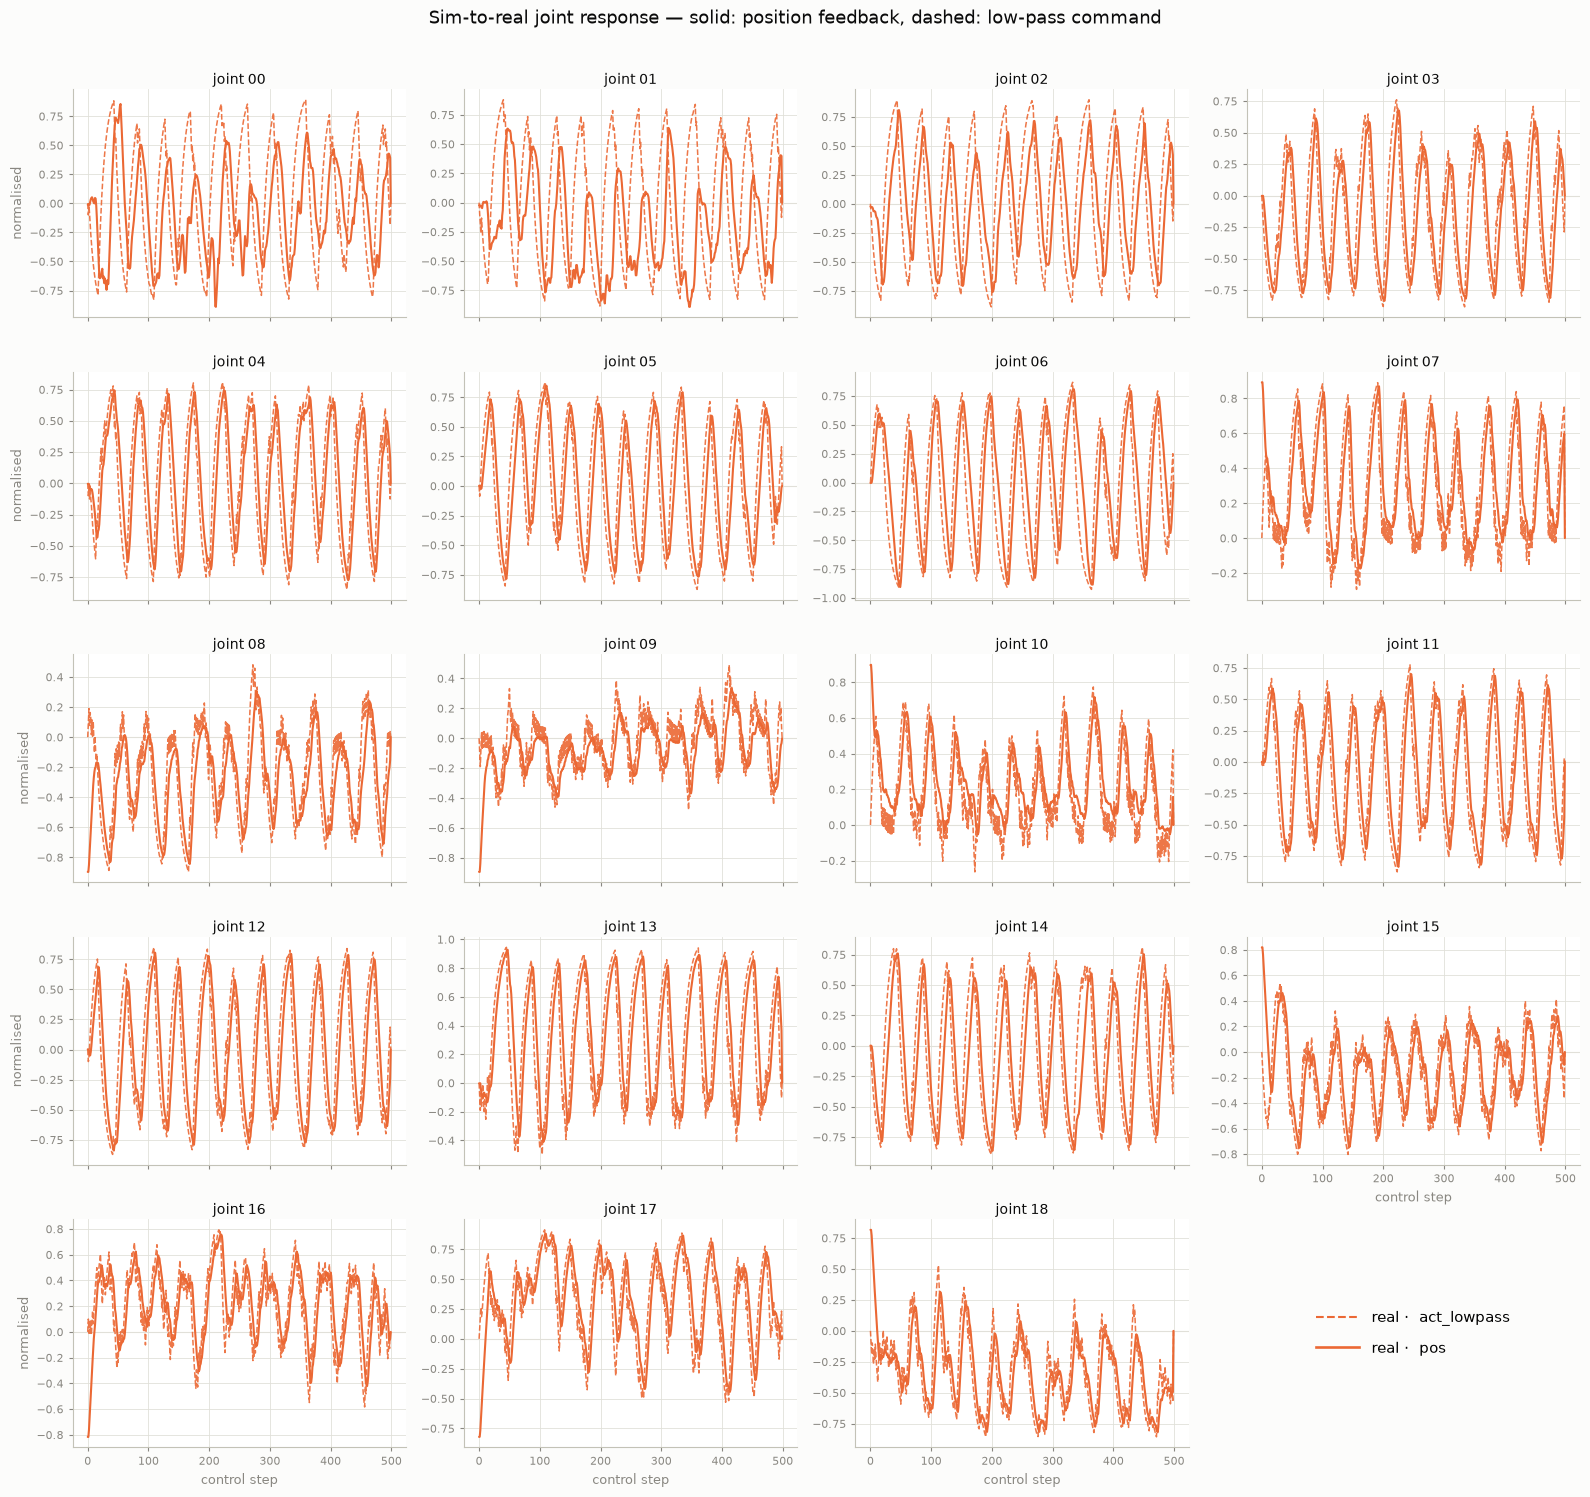

In [ ]:
# ---------------------------------------------------------------- config ----
import os

SIM_CASE, SIM_MODE, SIM_POLICY, SIM_ENV = flat, "pos_action", 0, 0
PATH = r"C:\Users\emper\Desktop\ICRA2026\locomotion_learning_information-theory\data\real_robot"
NAME = "s2r2.json"
REAL_BUFFER = os.path.join(PATH, NAME)

N_JOINT = 19
DT = None          # control period [s]; None -> x axis in control steps
NROW, NCOL = 5, 4  # 20 slots, last one holds the legend

FLIP_REAL_JOINTS = []

# ------------------------------------------------------------------ data ----
sim = SIM_CASE[SIM_MODE][SIM_POLICY]
sim_pos = np.asarray(sim["dof_pos_scaled"])[:, SIM_ENV, :N_JOINT]
sim_act = np.asarray(sim["action_lowpass"])[:, SIM_ENV, :N_JOINT]

with open(REAL_BUFFER) as f:
    buf = {k: np.asarray(v, dtype=np.float32) for k, v in json.load(f).items()}
# the buffer replays the same 500-step command sequence twice -> keep loop 1
n = sim_act.shape[0]
real_pos = buf["pos"][:n, :N_JOINT].copy()
real_act = buf["act_lowpass"][:n, :N_JOINT].copy()
if FLIP_REAL_JOINTS:
    real_pos[:, FLIP_REAL_JOINTS] *= -1.0
    real_act[:, FLIP_REAL_JOINTS] *= -1.0

t = np.arange(n) * DT if DT else np.arange(n)
xlabel = "time [s]" if DT else "control step"

# ------------------------------------------------------------------ style ---
C_SIM, C_REAL = "#2a78d6", "#eb6834"   # colour = domain, linestyle = signal
GRID, MUTED, INK = "#e1e0d9", "#898781", "#0b0b0b"
series = [                              # (y, colour, linestyle, lw, label)
    (real_act, C_REAL, "--", 1.1, "real ·  act_lowpass"),
    (real_pos, C_REAL, "-",  1.5, "real ·  pos"),
]

# ------------------------------------------------------------------- plot ---
fig, axes = plt.subplots(NROW, NCOL, figsize=(16, 15), sharex=True,
                         facecolor="#fcfcfb")
axes = axes.ravel()

for j in range(N_JOINT):
    ax = axes[j]
    for y, c, ls, lw, _ in series:
        ax.plot(t, y[:, j], color=c, ls=ls, lw=lw,
                alpha=1.0 if ls == "-" else 0.9, solid_capstyle="round")
    ax.axhline(0.0, color=GRID, lw=0.8, zorder=0)
    ax.grid(True, color=GRID, lw=0.6, zorder=0)
    ax.set_axisbelow(True)
    ax.set_title(f"joint {j:02d}", fontsize=10, color=INK, pad=4)
    ax.tick_params(labelsize=8, colors=MUTED, length=3)
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
    for s in ("left", "bottom"):
        ax.spines[s].set_color("#c3c2b7")
    if j % NCOL == 0:
        ax.set_ylabel("normalised", fontsize=9, color=MUTED)
    if j + NCOL >= N_JOINT:          # bottom-most subplot of its column
        ax.set_xlabel(xlabel, fontsize=9, color=MUTED)
        ax.tick_params(labelbottom=True)

# legend in the spare slot
legend_ax = axes[-1]
legend_ax.axis("off")
handles = [plt.Line2D([], [], color=c, ls=ls, lw=min(lw, 1.8) + 0.4, label=lab)
           for _, c, ls, lw, lab in series]
legend_ax.legend(handles=handles, loc="center", frameon=False, fontsize=11,
                 handlelength=2.8, labelspacing=1.0)
for k in range(N_JOINT, len(axes) - 1):
    axes[k].axis("off")

fig.suptitle("Sim-to-real joint response — solid: position feedback, dashed: low-pass command",
             fontsize=13, color=INK, y=0.995)
fig.tight_layout(rect=[0, 0, 1, 0.985])
fig.savefig("sim2real_joint_response.png", dpi=200, bbox_inches="tight",
            facecolor=fig.get_facecolor())
plt.show()

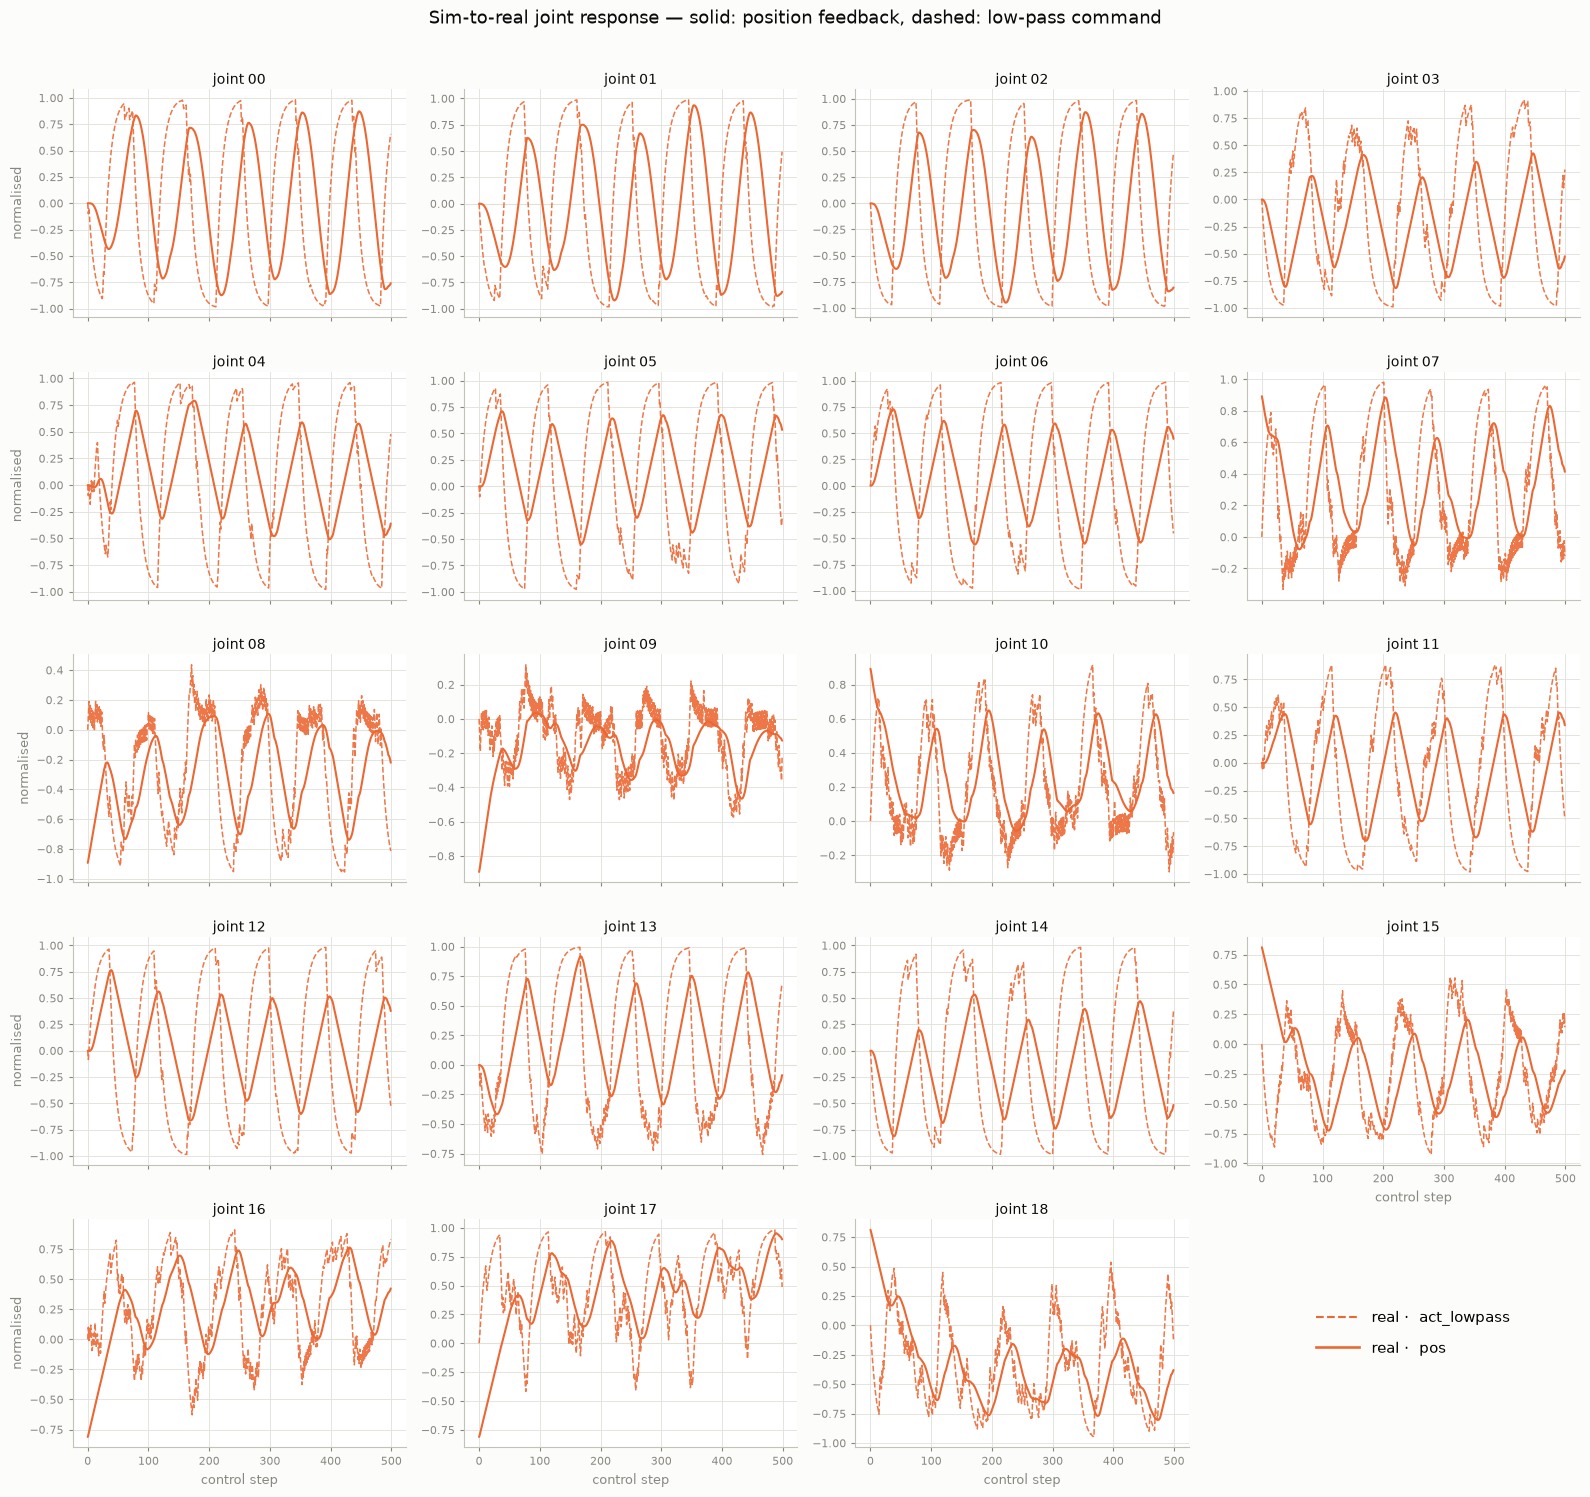

In [11]:
# ---------------------------------------------------------------- config ----
import os

SIM_CASE, SIM_MODE, SIM_POLICY, SIM_ENV = flat, "pos_action", 0, 0
PATH = r"C:\Users\emper\Desktop\ICRA2026\locomotion_learning_information-theory\data\real_robot\current_no_enough"
NAME = "pos_act_policy_buffer1.json"
REAL_BUFFER = os.path.join(PATH, NAME)

N_JOINT = 19
DT = None          # control period [s]; None -> x axis in control steps
NROW, NCOL = 5, 4  # 20 slots, last one holds the legend

FLIP_REAL_JOINTS = []

# ------------------------------------------------------------------ data ----
sim = SIM_CASE[SIM_MODE][SIM_POLICY]
sim_pos = np.asarray(sim["dof_pos_scaled"])[:, SIM_ENV, :N_JOINT]
sim_act = np.asarray(sim["action_lowpass"])[:, SIM_ENV, :N_JOINT]

with open(REAL_BUFFER) as f:
    buf = {k: np.asarray(v, dtype=np.float32) for k, v in json.load(f).items()}
# the buffer replays the same 500-step command sequence twice -> keep loop 1
n = sim_act.shape[0]
real_pos = buf["pos"][:n, :N_JOINT].copy()
real_act = buf["act_lowpass"][:n, :N_JOINT].copy()

t = np.arange(n) * DT if DT else np.arange(n)
xlabel = "time [s]" if DT else "control step"

# ------------------------------------------------------------------ style ---
C_SIM, C_REAL = "#2a78d6", "#eb6834"   # colour = domain, linestyle = signal
GRID, MUTED, INK = "#e1e0d9", "#898781", "#0b0b0b"
series = [                              # (y, colour, linestyle, lw, label)
    (sim_act, C_REAL, "--", 1.1, "real ·  act_lowpass"),
    (sim_pos, C_REAL, "-",  1.5, "real ·  pos"),
]

# ------------------------------------------------------------------- plot ---
fig, axes = plt.subplots(NROW, NCOL, figsize=(16, 15), sharex=True,
                         facecolor="#fcfcfb")
axes = axes.ravel()

for j in range(N_JOINT):
    ax = axes[j]
    for y, c, ls, lw, _ in series:
        ax.plot(t, y[:, j], color=c, ls=ls, lw=lw,
                alpha=1.0 if ls == "-" else 0.9, solid_capstyle="round")
    ax.axhline(0.0, color=GRID, lw=0.8, zorder=0)
    ax.grid(True, color=GRID, lw=0.6, zorder=0)
    ax.set_axisbelow(True)
    ax.set_title(f"joint {j:02d}", fontsize=10, color=INK, pad=4)
    ax.tick_params(labelsize=8, colors=MUTED, length=3)
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
    for s in ("left", "bottom"):
        ax.spines[s].set_color("#c3c2b7")
    if j % NCOL == 0:
        ax.set_ylabel("normalised", fontsize=9, color=MUTED)
    if j + NCOL >= N_JOINT:          # bottom-most subplot of its column
        ax.set_xlabel(xlabel, fontsize=9, color=MUTED)
        ax.tick_params(labelbottom=True)

# legend in the spare slot
legend_ax = axes[-1]
legend_ax.axis("off")
handles = [plt.Line2D([], [], color=c, ls=ls, lw=min(lw, 1.8) + 0.4, label=lab)
           for _, c, ls, lw, lab in series]
legend_ax.legend(handles=handles, loc="center", frameon=False, fontsize=11,
                 handlelength=2.8, labelspacing=1.0)
for k in range(N_JOINT, len(axes) - 1):
    axes[k].axis("off")

fig.suptitle("Sim-to-real joint response — solid: position feedback, dashed: low-pass command",
             fontsize=13, color=INK, y=0.995)
fig.tight_layout(rect=[0, 0, 1, 0.985])
fig.savefig("sim2real_joint_response.png", dpi=200, bbox_inches="tight",
            facecolor=fig.get_facecolor())
plt.show()